In [4]:
import anndata as ad
import torch
from torch import nn
from torch.utils.data import DataLoader
import pytorch_lightning as pl  # pyright: ignore[reportMissingImports]
from src.dataset import ScDataModule, ScDataset
from src.ae import LightningAE
import scanpy as sc  # pyright: ignore[reportMissingImports]
import os


adata = ad.read_h5ad('data/Alles_filtered.h5ad')
adata.var_names_make_unique()
display(adata.X)
display(adata.obs)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adatamodule = ScDataModule(adata, "cell_type1", "LabelEncoder")
ae_model = LightningAE(n_genes=adata.X.shape[1])

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs"
)

ae_model_path = "checkpoints/trained_ae_model.ckpt"
if os.path.exists(ae_model_path):
    # read the model from the checkpoint
    ae_model = LightningAE.load_from_checkpoint("checkpoints/trained_ae_model.ckpt")
else:
    trainer.fit(ae_model, adatamodule)
    trainer.save_checkpoint(ae_model_path)


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 5236395 stored elements and shape (4614, 11835)>

,cell_type1,data_type,cell_ontology_class,n_genes,n_counts
cell_id,,,,,
ACTTAGCGTTTN,undifferentiated cells,raw,nan,1588,5416
ATACACCCGCCC,undifferentiated cells,raw,nan,1165,4032
TCGGCGATGTAT,undifferentiated cells,raw,nan,1134,3992
GTTCGCCGTCGA,undifferentiated cells,raw,nan,1706,8109
CTAATCGCTAGT,undifferentiated cells,raw,nan,810,2743
...,...,...,...,...,...
TTTTAAGACGGN,LVM longitudinal visc. muscle,raw,visceral muscle cell,1027,3737
TCTTCACGAAGA,LVM longitudinal visc. muscle,raw,visceral muscle cell,1548,5824
GTTGCAATGGAG,LVM longitudinal visc. muscle,raw,visceral muscle cell,1136,3099


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
/var/folders/5z/8hzvmhln5p36t4tdqc9c52z40000gn/T/ipykernel_9931/638009657.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  markerfacecolor=plt.cm.get_cmap(cmap)(idx / max(1, len(classes)-1)),


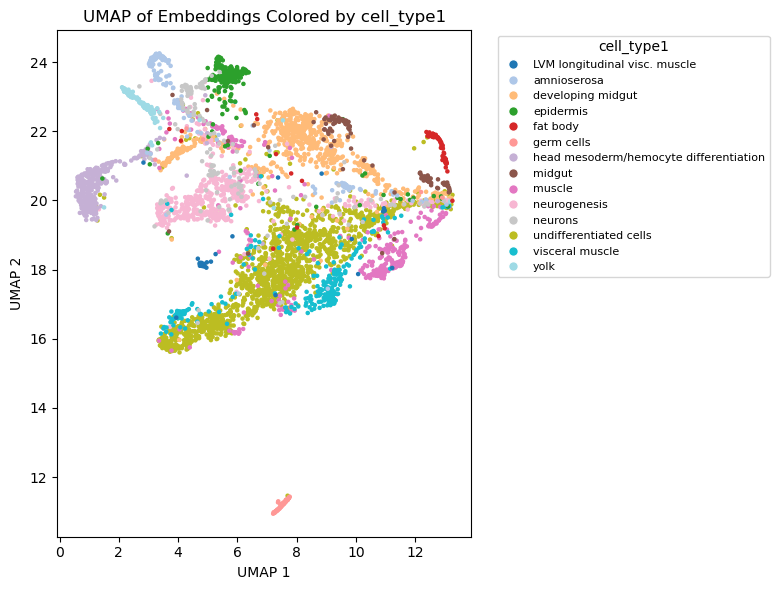

In [5]:
import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X_dense = adata.X.toarray()

# Convert to torch tensor and move to same device as model
device = next(ae_model.parameters()).device
X_tensor = torch.tensor(X_dense, dtype=torch.float32).to(device)

# Get embeddings
ae_model.eval()  # Set to evaluation mode
with torch.no_grad():  # Disable gradient computation for inference
    embeddings = ae_model.encoder(X_tensor)

# Convert embeddings to numpy array
if hasattr(embeddings, 'detach'):
    emb_np = embeddings.detach().cpu().numpy()
else:
    emb_np = embeddings

def plot_umap_embeddings(embeddings, labels, title="UMAP of Embeddings Colored by cell_type1", cmap='tab20', figsize=(8,6), random_state=42):

    # Fit UMAP if input embeddings is not already 2D
    if embeddings.shape[1] != 2:
        umap_model = umap.UMAP(n_components=2, random_state=random_state)
        emb_umap = umap_model.fit_transform(embeddings)
    else:
        emb_umap = embeddings

    # Ensure labels are a numpy array and categorical
    labels = np.array(labels)
    cat = pd.Categorical(labels)
    label_codes = cat.codes
    classes = cat.categories

    plt.figure(figsize=figsize)
    scatter = plt.scatter(emb_umap[:, 0], emb_umap[:, 1], 
                         c=label_codes, cmap=cmap, s=5)
    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    handles = []
    for idx, class_name in enumerate(classes):
        handles.append(
            plt.Line2D([], [], marker='o', color='w', label=class_name,
                       markerfacecolor=plt.cm.get_cmap(cmap)(idx / max(1, len(classes)-1)),
                       markersize=7))
    plt.legend(handles=handles, title='cell_type1', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_umap_embeddings(
    emb_np,                              # The embeddings from AE
    adata.obs['cell_type1'],             # The cell type labels
    title="UMAP of Embeddings Colored by cell_type1"
)


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
/var/folders/5z/8hzvmhln5p36t4tdqc9c52z40000gn/T/ipykernel_9931/638009657.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  markerfacecolor=plt.cm.get_cmap(cmap)(idx / max(1, len(classes)-1)),


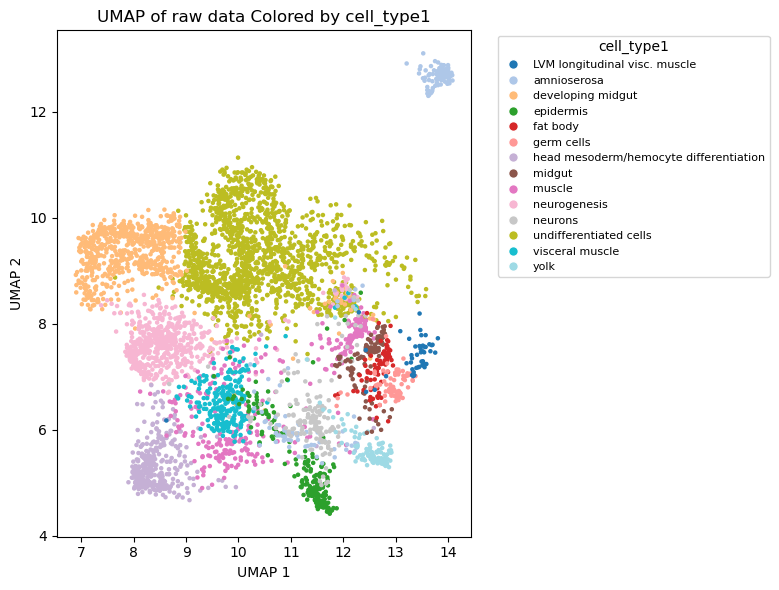

In [6]:
plot_umap_embeddings(
    adata.X,
    adata.obs['cell_type1'],
    title="UMAP of raw data Colored by cell_type1"
)